In [ ]:
# B1: Load Brown Corpus

import nltk
from nltk.corpus import brown

nltk.download('brown')


# News category
brown_words = brown.words(categories='news')

print("Number of words:", len(brown_words))
print("First 20 words:", brown_words[:20])

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.


Number of words: 100554
First 20 words: ['The', 'Fulton', 'County', 'Grand', 'Jury', 'said', 'Friday', 'an', 'investigation', 'of', "Atlanta's", 'recent', 'primary', 'election', 'produced', '``', 'no', 'evidence', "''", 'that']


In [ ]:
# B2: Convert Brown Corpus to string and tokenize
nltk.download('punkt_tab')
text = ' '.join(brown_words)

tokens = nltk.word_tokenize(text)

print("First 50 tokens:")
print(tokens[:50])

print("\nTotal number of tokens:", len(tokens))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


First 50 tokens:
['The', 'Fulton', 'County', 'Grand', 'Jury', 'said', 'Friday', 'an', 'investigation', 'of', 'Atlanta', "'s", 'recent', 'primary', 'election', 'produced', '``', 'no', 'evidence', '``', 'that', 'any', 'irregularities', 'took', 'place', '.', 'The', 'jury', 'further', 'said', 'in', 'term-end', 'presentments', 'that', 'the', 'City', 'Executive', 'Committee', ',', 'which', 'had', 'over-all', 'charge', 'of', 'the', 'election', ',', '``', 'deserves', 'the']

Total number of tokens: 101929


In [ ]:
# B3: Calculate raw word frequencies

from nltk.probability import FreqDist

frequency_distribution = FreqDist(tokens)

print("Total unique tokens:", len(frequency_distribution))

print("\nTop 20 most frequent words:")
print(frequency_distribution.most_common(20))


Total unique tokens: 13900

Top 20 most frequent words:
[('the', 5580), (',', 5188), ('.', 4180), ('of', 2849), ('and', 2146), ('to', 2116), ('a', 1993), ('in', 1893), ('``', 1434), ('for', 943), ('that', 811), ('The', 806), ('is', 739), ('was', 720), ("'s", 679), ('on', 657), ('at', 598), ('with', 545), ('be', 526), ('by', 497)]


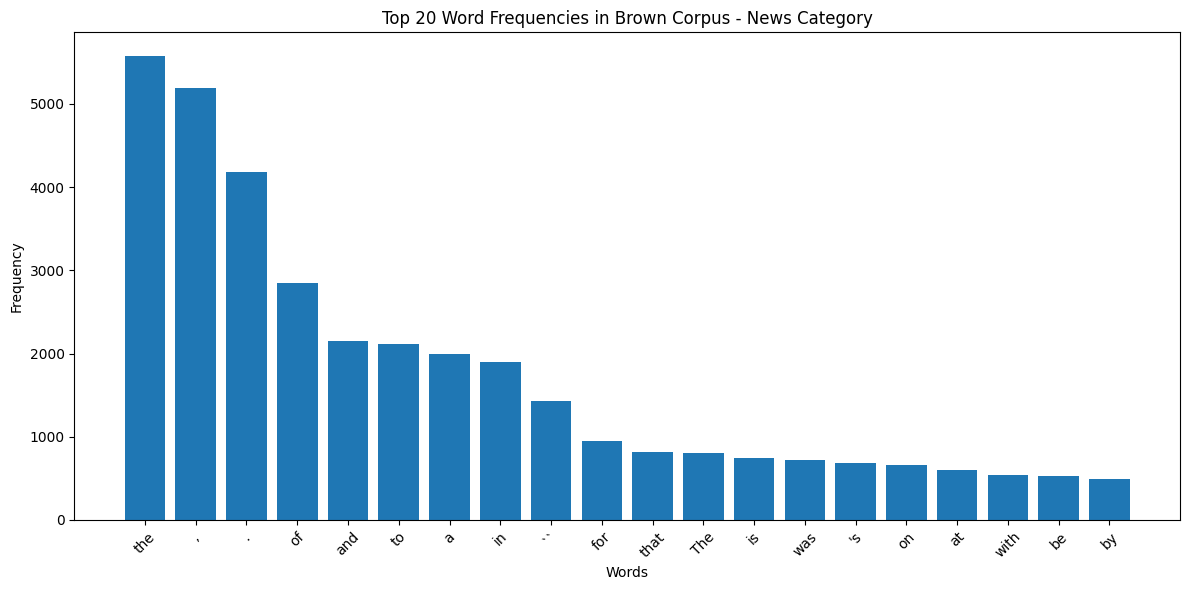

In [ ]:
# B4: Visualize top 20 word frequencies using a bar chart

import matplotlib.pyplot as plt

top_20 = frequency_distribution.most_common(20)

words = [word for word, frequency in top_20]
frequencies = [frequency for word, frequency in top_20]

plt.figure(figsize=(12, 6))
plt.bar(words, frequencies)

plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 20 Word Frequencies in Brown Corpus - News Category")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

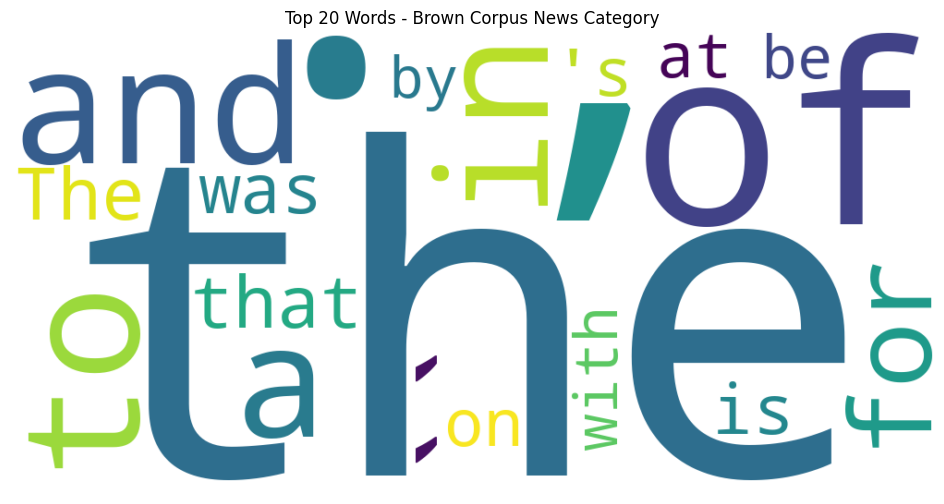

In [ ]:
# B5: Word cloud of top 20 words

from wordcloud import WordCloud

# Create a dictionary of the top 20 words and their frequencies
top_20_dict = dict(frequency_distribution.most_common(20))


wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate_from_frequencies(top_20_dict)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Top 20 Words - Brown Corpus News Category")
plt.show()

In [ ]:
# B6: Apply Porter Stemmer

from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

stemmed_tokens = [stemmer.stem(word) for word in tokens]

print("First 50 stemmed tokens:")
print(stemmed_tokens[:50])

First 50 stemmed tokens:
['the', 'fulton', 'counti', 'grand', 'juri', 'said', 'friday', 'an', 'investig', 'of', 'atlanta', "'s", 'recent', 'primari', 'elect', 'produc', '``', 'no', 'evid', '``', 'that', 'ani', 'irregular', 'took', 'place', '.', 'the', 'juri', 'further', 'said', 'in', 'term-end', 'present', 'that', 'the', 'citi', 'execut', 'committe', ',', 'which', 'had', 'over-al', 'charg', 'of', 'the', 'elect', ',', '``', 'deserv', 'the']


In [ ]:
# B7: Calculate frequency of stemmed words

stem_frequency = FreqDist(stemmed_tokens)

print("Total unique stems:", len(stem_frequency))

print("\nTop 20 stemmed words:")
print(stem_frequency.most_common(20))

Total unique stems: 9286

Top 20 stemmed words:
[('the', 6386), (',', 5188), ('.', 4180), ('of', 2861), ('and', 2186), ('to', 2144), ('a', 2139), ('in', 2020), ('``', 1434), ('for', 969), ('that', 843), ('is', 740), ('wa', 720), ('on', 691), ('it', 682), ("'s", 679), ('he', 658), ('at', 636), ('be', 583), ('with', 567)]


In [ ]:
# B8: Apply WordNet Lemmatizer

from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

lemmatized_tokens = [lemmatizer.lemmatize(word) for word in tokens]

print("First 50 lemmatized tokens:")
print(lemmatized_tokens[:50])

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


First 50 lemmatized tokens:
['The', 'Fulton', 'County', 'Grand', 'Jury', 'said', 'Friday', 'an', 'investigation', 'of', 'Atlanta', "'s", 'recent', 'primary', 'election', 'produced', '``', 'no', 'evidence', '``', 'that', 'any', 'irregularity', 'took', 'place', '.', 'The', 'jury', 'further', 'said', 'in', 'term-end', 'presentment', 'that', 'the', 'City', 'Executive', 'Committee', ',', 'which', 'had', 'over-all', 'charge', 'of', 'the', 'election', ',', '``', 'deserves', 'the']


In [ ]:
# B9: Calculate frequency of lemmatized words

lemma_frequency = FreqDist(lemmatized_tokens)

print("Total unique lemmas:", len(lemma_frequency))

print("\nTop 20 lemmatized words:")
print(lemma_frequency.most_common(20))

Total unique lemmas: 12806

Top 20 lemmatized words:
[('the', 5580), (',', 5188), ('.', 4180), ('of', 2849), ('a', 2474), ('and', 2146), ('to', 2116), ('in', 1893), ('``', 1434), ('for', 943), ('that', 811), ('The', 806), ('is', 739), ('wa', 720), ("'s", 679), ('on', 657), ('at', 598), ('it', 549), ('with', 545), ('be', 526)]


In [ ]:
# B10: Compare Stemming vs Lemmatization

import pandas as pd

# Select 15 common alphabetic words
common_words = []

for word, frequency in frequency_distribution.most_common():
    if word.isalpha():
        common_words.append(word)

    if len(common_words) == 15:
        break

# Create comparison data
comparison_data = []

for word in common_words:
    stem = stemmer.stem(word)
    lemma = lemmatizer.lemmatize(word)

    comparison_data.append({
        "Original Word": word,
        "Stemmed Word": stem,
        "Lemmatized Word": lemma,
        "Stem Frequency": stem_frequency[stem],
        "Lemma Frequency": lemma_frequency[lemma]
    })

comparison_df = pd.DataFrame(comparison_data)

comparison_df

,Original Word,Stemmed Word,Lemmatized Word,Stem Frequency,Lemma Frequency
0,the,the,the,6386,5580
1,of,of,of,2861,2849
2,and,and,and,2186,2146
3,to,to,to,2144,2116
4,a,a,a,2139,2474
5,in,in,in,2020,1893
6,for,for,for,969,943
7,that,that,that,843,811
8,The,the,The,6386,806
9,is,is,is,740,739
